---
# Measurement p
---

In [ ]:
from observables import initialize_data
from plotting import (
    plot_entropy_subplots,
    plot_entropy_vs_p_fixed_L,
)

In [ ]:
"""Plotting functions for the thesis results."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D


# =============================================================================
# ENTROPY VS SYSTEM SIZE
# =============================================================================

def plot_entropy_vs_L(p_values, dimensions, S_matrix, S_matrix_std, p_c, vmin=0.0, vmax=1.0):
    """Plot the mean entropy against the system size for different probabilities."""

    colors_lower = plt.cm.Blues_r(np.linspace(0.0, 0.65, 128))
    colors_upper = plt.cm.Reds(np.linspace(0.35, 1.0, 128))
    colors_combined = np.vstack((colors_lower, colors_upper))
    custom_cmap = mcolors.ListedColormap(colors_combined, name="BlueRed_Visible")

    effective_vmax = vmax
    if p_c >= vmax:
        effective_vmax = p_c + 1e-5

    norm = mcolors.TwoSlopeNorm(vcenter=p_c, vmin=vmin, vmax=effective_vmax)
    fig, ax = plt.subplots(figsize=(11, 7))

    num_lines_to_plot = 12
    indices_to_plot = np.linspace(0, len(p_values) - 1, num_lines_to_plot, dtype=int)

    for idx in indices_to_plot:
        p = p_values[idx]
        means = S_matrix[:, idx]
        stds = S_matrix_std[:, idx]
        color = custom_cmap(norm(p))

        ax.plot(dimensions, means, "-o", color=color, linewidth=3.5, markersize=9, alpha=0.9)
        ax.fill_between(dimensions, means - stds, means + stds, color=color, alpha=0.2, edgecolor="none")

    sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, pad=0.05, aspect=20)
    cbar.set_label(r"$p$", fontsize=28, labelpad=15)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.ax.tick_params(labelsize=22)
    cbar.ax.invert_yaxis()
    cbar.ax.axhline(p_c, color="black", linewidth=3, linestyle="-")
    cbar.ax.text(-0.17, p_c, r"$p_c$", color="black", va="center", ha="right", fontsize=24)

    ax.set_xlabel(r"$L$", fontsize=28)
    ax.set_ylabel(r"$\langle S \rangle$", fontsize=28)
    ax.tick_params(axis="both", which="major", labelsize=24, width=2, length=6)
    ax.ticklabel_format(style="sci", axis="y", scilimits=(3, 3), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(22)
    ax.set_xlim(dimensions[0] - 10, dimensions[-1] + 10)
    ax.grid(alpha=0.4, linestyle="--")

    plt.tight_layout()
    plt.show()


# =============================================================================
# CV AND DV ENTROPY VS PROBABILITY AT FIXED L
# =============================================================================

def plot_CV_vs_DV_fixed_L(p_values, dimensions, S_matrix, S_matrix_std, S_DV_matrix, S_DV_matrix_std,
                          target_L, p_c=0.4070, p_err_minus=0.0003, p_err_plus=0.0010,
                          r_fixed=0.0, w_fixed=1.0):
    """
    Compare CV and DV entanglement entropy against measurement probability
    for a fixed system size L.
    """

    if target_L not in dimensions:
        raise ValueError(f"Target L={target_L} not found in the dimensions array {dimensions}")

    l_idx = np.where(dimensions == target_L)[0][0]

    cv_means = S_matrix[l_idx, :]
    cv_stds = S_matrix_std[l_idx, :]
    dv_means = S_DV_matrix[l_idx, :]
    dv_stds = S_DV_matrix_std[l_idx, :]

    styles = {
        "CV": {"color": "tab:purple", "ls": "-", "marker": "o", "lw": 4, "ms": 9},
        "DV": {"color": "tab:orange", "ls": "--", "marker": "s", "lw": 4, "ms": 9},
    }

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.plot(p_values, cv_means, color=styles["CV"]["color"], linestyle=styles["CV"]["ls"],
            marker=styles["CV"]["marker"], linewidth=styles["CV"]["lw"],
            markersize=styles["CV"]["ms"], zorder=5)

    ax.fill_between(p_values, cv_means - cv_stds, cv_means + cv_stds,
                    color=styles["CV"]["color"], alpha=0.2, edgecolor="none", zorder=4)

    ax.plot(p_values, dv_means, color=styles["DV"]["color"], linestyle=styles["DV"]["ls"],
            marker=styles["DV"]["marker"], linewidth=styles["DV"]["lw"],
            markersize=styles["DV"]["ms"], zorder=5)

    ax.fill_between(p_values, dv_means - dv_stds, dv_means + dv_stds,
                    color=styles["DV"]["color"], alpha=0.2, edgecolor="none", zorder=4)

    ax.axvline(x=p_c, color="black", linestyle="--", linewidth=4, zorder=10)
    ax.axvspan(p_c - p_err_minus, p_c + p_err_plus, color="black", alpha=0.15, zorder=9)

    error_text = rf"$p_c = {p_c:.4f}_{{-{p_err_minus:.4f}}}^{{+{p_err_plus:.4f}}}$"
    y_text_pos = np.nanmax(cv_means) * 0.5
    ax.text(p_c + 0.02, y_text_pos, error_text, color="black", fontsize=26, va="center")

    ax.set_xlabel(r"$p$", fontsize=28)
    ax.set_ylabel(r"$\langle S \rangle/L$", fontsize=28)
    ax.set_xlim(p_values[0] - 0.02, p_values[-1] + 0.02)
    ax.tick_params(axis="both", which="major", labelsize=24, width=2, length=6)
    ax.grid(alpha=0.4, linestyle="--")

    legend_elements = [
        Line2D([0], [0], color=styles["CV"]["color"], linestyle=styles["CV"]["ls"],
               marker=styles["CV"]["marker"], lw=styles["CV"]["lw"], ms=styles["CV"]["ms"],
               label="Continuous Variable (CV)"),
        Line2D([0], [0], color=styles["DV"]["color"], linestyle=styles["DV"]["ls"],
               marker=styles["DV"]["marker"], lw=styles["DV"]["lw"], ms=styles["DV"]["ms"],
               label="Discrete Variable (DV)"),
    ]

    ax.legend(handles=legend_elements, loc="upper right", fontsize=22, frameon=True, facecolor="white")

    plt.tight_layout()
    plt.show()


# =============================================================================
# CV AND DV ENTROPY VS SYSTEM SIZE WITH INSET
# =============================================================================

def plot_CV_vs_DV_with_inset(p_values_all, dimensions, S_matrix, S_matrix_std,
                             S_DV_matrix, S_DV_matrix_std, p_ordered=0.30, p_disordered=0.55):
    """
    Plot the ordered phase on the main axis and the disordered phase
    in an inset.
    """

    fig, ax = plt.subplots(figsize=(11, 7))

    color_CV = "tab:purple"
    color_DV = "tab:orange"

    idx_ord = np.argmin(np.abs(p_values_all - p_ordered))
    idx_dis = np.argmin(np.abs(p_values_all - p_disordered))

    actual_p_ord = p_values_all[idx_ord]
    actual_p_dis = p_values_all[idx_dis]

    # Main plot: ordered phase
    ax.plot(dimensions, S_matrix[:, idx_ord], color=color_CV, ls="-", marker="o", lw=3.5, ms=8, zorder=5)
    ax.fill_between(dimensions, S_matrix[:, idx_ord] - S_matrix_std[:, idx_ord],
                    S_matrix[:, idx_ord] + S_matrix_std[:, idx_ord],
                    color=color_CV, alpha=0.2, edgecolor="none", zorder=4)

    ax.plot(dimensions, S_DV_matrix[:, idx_ord], color=color_DV, ls="--", marker="s", lw=3.5, ms=8, zorder=5)
    ax.fill_between(dimensions, S_DV_matrix[:, idx_ord] - S_DV_matrix_std[:, idx_ord],
                    S_DV_matrix[:, idx_ord] + S_DV_matrix_std[:, idx_ord],
                    color=color_DV, alpha=0.2, edgecolor="none", zorder=4)

    ax.set_xlabel(r"$L$", fontsize=26)
    ax.set_ylabel(r"$\langle S \rangle$", fontsize=26)
    ax.tick_params(axis="both", which="major", labelsize=22, width=2, length=6)
    ax.grid(alpha=0.3, linestyle="--")

    ax.text(0.52, 0.12, rf"Ordered Phase ($p = {actual_p_ord:.2f}$)", transform=ax.transAxes,
            fontsize=22, fontweight="bold", va="top", ha="left",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.4"))

    legend_elements = [
        Line2D([0], [0], color=color_CV, marker="o", ls="-", lw=3.5, ms=8, label="Continuous Variable (CV)"),
        Line2D([0], [0], color=color_DV, marker="s", ls="--", lw=3.5, ms=8, label="Discrete Variable (DV)"),
    ]

    ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.52, 0.52),
              fontsize=18, frameon=True, facecolor="white", edgecolor="gray")

    # Inset: disordered phase
    axins = ax.inset_axes([0.05, 0.45, 0.45, 0.45])

    axins.plot(dimensions, S_matrix[:, idx_dis], color=color_CV, ls="-", marker="o", lw=2.5, ms=6, zorder=5)
    axins.fill_between(dimensions, S_matrix[:, idx_dis] - S_matrix_std[:, idx_dis],
                       S_matrix[:, idx_dis] + S_matrix_std[:, idx_dis],
                       color=color_CV, alpha=0.2, edgecolor="none", zorder=4)

    axins.plot(dimensions, S_DV_matrix[:, idx_dis], color=color_DV, ls="--", marker="s", lw=2.5, ms=6, zorder=5)
    axins.fill_between(dimensions, S_DV_matrix[:, idx_dis] - S_DV_matrix_std[:, idx_dis],
                       S_DV_matrix[:, idx_dis] + S_DV_matrix_std[:, idx_dis],
                       color=color_DV, alpha=0.2, edgecolor="none", zorder=4)

    axins.set_title(rf"Disordered Phase ($p = {actual_p_dis:.2f}$)", fontsize=18, fontweight="bold")
    axins.tick_params(axis="both", which="major", labelsize=16)
    axins.grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()


# =============================================================================
# ENTROPY VS SYSTEM SIZE FOR DIFFERENT MEASUREMENT ANGLES
# =============================================================================

def plot_entropy_subplots(datasets, p_c, phi_labels, vmin=0.0, vmax=1.0):
    """
    Plot entropy against system size for three measurement angles.

    Each dataset must contain:
    (p_values, dimensions, S_matrix, S_matrix_std)
    """

    colors_lower = plt.cm.Blues_r(np.linspace(0.0, 0.65, 128))
    colors_upper = plt.cm.Reds(np.linspace(0.35, 1.0, 128))
    colors_combined = np.vstack((colors_lower, colors_upper))

    cmap_1 = mcolors.ListedColormap(colors_combined, name="BlueRed_Visible")
    norm_1 = mcolors.TwoSlopeNorm(vcenter=p_c, vmin=vmin, vmax=vmax)

    colors_blue = plt.cm.Blues_r(np.linspace(0.0, 0.55, 256))
    cmap_2 = mcolors.ListedColormap(colors_blue, name="Blues_Visible")
    norm_2 = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    num_lines_to_plot = 12

    for i, ax in enumerate(axes):
        p_values, dimensions, S_matrix, S_matrix_std = datasets[i]

        if i == 0:
            current_cmap, current_norm = cmap_1, norm_1
        else:
            current_cmap, current_norm = cmap_2, norm_2

        indices_to_plot = np.linspace(0, len(p_values) - 1, num_lines_to_plot, dtype=int)

        for idx in indices_to_plot:
            p = p_values[idx]
            means = S_matrix[:, idx]
            stds = S_matrix_std[:, idx]
            color = current_cmap(current_norm(p))

            ax.plot(dimensions, means, "-o", color=color, linewidth=2.5, markersize=6, alpha=0.9)
            ax.fill_between(dimensions, means - stds, means + stds,
                            color=color, alpha=0.2, edgecolor="none")

        ax.set_xlabel(r"$L$", fontsize=22)
        ax.set_title(phi_labels[i], fontsize=24, pad=15)
        ax.tick_params(axis="both", which="major", labelsize=18)
        ax.ticklabel_format(style="plain", axis="y", useOffset=False)
        ax.set_xlim(dimensions[0] - 2, dimensions[-1] + 2)
        ax.grid(alpha=0.4, linestyle="--")

        if i == 0:
            ax.set_ylabel(r"$\langle S \rangle$", fontsize=22)

    sm1 = cm.ScalarMappable(cmap=cmap_1, norm=norm_1)
    sm1.set_array([])

    cbar1 = fig.colorbar(sm1, ax=axes[0], pad=0.03, aspect=20)
    cbar1.set_label(r"$p$", fontsize=20, labelpad=10)
    cbar1.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar1.ax.tick_params(labelsize=16)
    cbar1.ax.invert_yaxis()
    cbar1.ax.axhline(p_c, color="black", linewidth=3, linestyle="-")
    cbar1.ax.text(-0.17, p_c, r"$p_c$", color="black", va="center", ha="right", fontsize=18)

    sm2 = cm.ScalarMappable(cmap=cmap_2, norm=norm_2)
    sm2.set_array([])

    cbar2 = fig.colorbar(sm2, ax=axes[2], pad=0.03, aspect=20)
    cbar2.set_label(r"$p$", fontsize=20, labelpad=10)
    cbar2.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar2.ax.tick_params(labelsize=16)
    cbar2.ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


# =============================================================================
# ENTROPY VS PROBABILITY FOR DIFFERENT MEASUREMENT ANGLES
# =============================================================================

def plot_entropy_vs_p_fixed_L(datasets, target_L, phi_labels):
    """
    Plot entropy against measurement probability for a fixed system size.

    Each dataset must contain:
    (p_values, dimensions, S_matrix, S_matrix_std)
    """

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ["#08519c", "#cb181d", "#238b45"]
    markers = ["o", "s", "^"]

    for i, data in enumerate(datasets):
        p_values, dimensions, S_matrix, S_matrix_std = data

        if target_L not in dimensions:
            raise ValueError(f"Target L={target_L} not found in dimensions array {dimensions}")

        l_idx = np.where(dimensions == target_L)[0][0]
        means = S_matrix[l_idx, :]
        stds = S_matrix_std[l_idx, :]

        ax.plot(p_values, means, marker=markers[i], color=colors[i], linewidth=2.5,
                markersize=7, label=phi_labels[i], alpha=0.9, markevery=5)

        ax.fill_between(p_values, means - stds, means + stds,
                        color=colors[i], alpha=0.15, edgecolor="none")

    ax.set_xlabel(r"$p$", fontsize=22)
    ax.set_ylabel(r"$\langle S \rangle/L$", fontsize=22)
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.yaxis.get_offset_text().set_fontsize(16)
    ax.set_xlim(p_values[0], p_values[-1])
    ax.legend(fontsize=18, loc="best", frameon=True, edgecolor="black", shadow=True)
    ax.grid(alpha=0.4, linestyle="--")

    plt.tight_layout()
    plt.show()

In [117]:
# initialise everything for p
import fssa 
import numpy as np
from scipy.signal import savgol_filter

import pickle
import numpy as np


def initialize_data(file_name, meas):
    """
    Carga los datos desde un archivo pickle y devuelve el diccionario de datos.
    """

    with open(file_name, 'rb') as f:
        data = pickle.load(f)

    def percolation(p, L, data):
        """
        Recorre todos los valores de 'p' guardados para una dimensión L fija.
        """
    
        total_nodes_original = L * L 
        
        # Recuperamos la lista con los tamaños del LCC de las 200 realizaciones
        lcc_sizes = data['results'][p][L]['LCC_sizes']
        
        p_cc_realizations = []
        for size in lcc_sizes:
            # En tu código original dividías por los nodos supervivientes.
            # Como la probabilidad de borrar es p, los supervivientes son aprox (1-p)*total
            surviving_nodes = total_nodes_original * (1 - p)
            
            if surviving_nodes > 0:
                p_cc_realizations.append(size / total_nodes_original)
            else:
                p_cc_realizations.append(0.0)
                
        avg_p_cc = np.mean(p_cc_realizations)
        std_p_cc = np.std(p_cc_realizations)
            
        return avg_p_cc, std_p_cc


    def P_vs_L(data, p_target, L):

        p_values = data['p_values']
        
        # TRUCO VITAL: Encontrar la p guardada más cercana a p_target para evitar 
        # errores de precisión flotante (ej. 0.30000000000000004 vs 0.3)
        idx = np.argmin(np.abs(p_values - p_target))
        p_closest = p_values[idx]
        
        lcc_sizes = data['results'][p_closest][L]['LCC_sizes']
        
        total_nodes_original = L * L
        surviving_nodes = total_nodes_original * (1 - p_closest)
        
        p_cc_realizations = []
        for size in lcc_sizes:
            if surviving_nodes > 0:
                p_cc_realizations.append(size / total_nodes_original)
            else:
                p_cc_realizations.append(0.0)
                
        avg_p_cc = np.mean(p_cc_realizations)
        
        return avg_p_cc

    def entropy_from_topology(p, L, data, r, meas='q'):

        def exact_f_r(A_eff, r):
            # ... (keep your exact_f_r the same) ...
            nu = np.sqrt(1 + (A_eff ** 2)*np.exp(4*r))
            eps = 1e-12 
            term1 = ((nu + 1) / 2) * np.log2(((nu + 1) / 2) + eps)
            term2 = ((nu - 1) / 2) * np.log2(((nu - 1) / 2) + eps)
            return term1 - term2

        def all_equal(iterable):
            it = iter(iterable)
            return all(a == b for a, b in zip(it, it))

        spectra = data['results'][p][L]['eigenvalues']
        
        # Promedio Cuántico (Calculamos la entropía al vuelo usando el espectro)
        entropies = []
        for eigenvalues in spectra:
            if meas in ['q', 'z', 'Z']:
                if len(eigenvalues) == 0:
                    entropies.append(0.0)
                elif all_equal(eigenvalues):
                    # Si todos los autovalores son iguales, podemos usar la fórmula simplificada
                    weight = eigenvalues[0]
                    S = exact_f_r(weight, r) * len(eigenvalues)
                    entropies.append(S/L)
                else:
                    # Tu fórmula física:
                    S = sum([exact_f_r(w, r) for w in eigenvalues])
                    entropies.append(S/L)
            elif meas in ['CV general', 'CV', 'general']:
                if len(eigenvalues) == 0:
                    entropies.append(0.0)
                else:
                    n = eigenvalues - 0.5
                    h2 = (n + 1) * np.log2(n + 1) - n * np.log2(np.clip(n, 1e-15, None))
                    entropies.append(np.sum(h2))
            
        S_matrix = np.mean(entropies)
        S_matrix_std = np.std(entropies, ddof=1)

        return S_matrix, S_matrix_std

    def entropy_DV(p, L, data):
        S = data['results'][p][L]['dv_entropies']
        entropies = []
        for entropy in S:
            entropies.append(entropy/L)
                
        S_matrix = np.mean(entropies)
        S_matrix_std = np.std(entropies, ddof=1)

        return S_matrix, S_matrix_std

    # 1. Cargar los datos
    with open(file_name, 'rb') as f:
        data = pickle.load(f)

    p_values_full = data['p_values']
    dimensions = data['L_values']
    r = 1.0 
    
    # =================================================================
    # THE FIX: FILTER OUT UNFINISHED SIMULATION DATA
    # =================================================================
    valid_p_values = []
    for p in p_values_full:
        # Check if the p exists AND if all dimensions finished calculating
        if p in data['results'] and len(data['results'][p]) == len(dimensions):
            valid_p_values.append(p)
            
    p_values = np.array(valid_p_values)
    
    if len(p_values) == 0:
        print("[WARNING] No complete data found in this file!")
        return [], [], [], [], [], []
    else:
        print(f"[INFO] Successfully loaded {len(p_values)} / {len(p_values_full)} completed p-values.")
    # =================================================================

    # Matrices para guardar los resultados promediados (now using the filtered length)
    S_matrix = np.zeros((len(dimensions), len(p_values)))
    C_matrix = np.zeros((len(dimensions), len(p_values)))
    C_matrix_std = np.zeros((len(dimensions), len(p_values)))
    S_matrix_std = np.zeros((len(dimensions), len(p_values)))

    for i, L in enumerate(dimensions):
        for j, p in enumerate(p_values): # Loops safely only over finished p's
            
            C_matrix[i, j], C_matrix_std[i, j] = percolation(p, L, data)      
            S_matrix[i, j], S_matrix_std[i, j] = entropy_from_topology(p, L, data, r, meas)
            
    return p_values, dimensions, C_matrix, C_matrix_std, S_matrix, S_matrix_std#, S_DV_matrix, S_DV_matrix_std

In [118]:
# def plot S vs L
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_entropy_vs_L(p_values, dimensions, S_matrix, S_matrix_std, p_c, vmin=0.0, vmax=1.0):
    # ==========================================
    # 1. CONDITIONAL COLORMAP & NORM
    # ==========================================
    if p_c >= vmax:
        # --- FIXED: Tighter truncation of Blues_r ---
        # We sample from 0.0 (Dark Blue) and stop at 0.55 (Medium Blue)
        # This guarantees the highest p lines remain distinct and visible.
        colors_blue = plt.cm.Blues_r(np.linspace(0.0, 0.55, 256))
        custom_cmap = mcolors.ListedColormap(colors_blue, name='Blues_Visible')
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        show_pc = False
    else:
        # Phase transition exists (Two-Slope mapping)
        colors_lower = plt.cm.Blues_r(np.linspace(0.0, 0.65, 128)) 
        colors_upper = plt.cm.Reds(np.linspace(0.35, 1.0, 128))    
        colors_combined = np.vstack((colors_lower, colors_upper))
        custom_cmap = mcolors.ListedColormap(colors_combined, name='BlueRed_Visible')
        norm = mcolors.TwoSlopeNorm(vcenter=p_c, vmin=vmin, vmax=vmax)
        show_pc = True

    # ==========================================
    # 2. PLOTTING THE RESULTS
    # ==========================================
    fig, ax = plt.subplots(figsize=(11, 7))

    num_lines_to_plot = 12
    indices_to_plot = np.linspace(0, len(p_values) - 1, num_lines_to_plot, dtype=int)

    for idx in indices_to_plot:
        p = p_values[idx]
        means = S_matrix[:, idx]
        stds = S_matrix_std[:, idx] 
        
        color = custom_cmap(norm(p))
        ax.plot(dimensions, means, '-o', color=color, linewidth=2, markersize=7, alpha=0.9)
        ax.fill_between(dimensions, means - stds, means + stds, color=color, alpha=0.2, edgecolor='none')

    # ==========================================
    # 3. COLORBAR FORMATTING
    # ==========================================
    sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, pad=0.05, aspect=20)
    cbar.set_label(r'$p$', fontsize=22, labelpad=15)
    
    # Force the ticks to be equidistant
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.ax.tick_params(labelsize=20)
    
    # This specifically puts 0.0 at the top and 1.0 at the bottom
    cbar.ax.invert_yaxis()

    # Only draw the critical point line if a transition actually exists
    if show_pc:
        cbar.ax.axhline(p_c, color='black', linewidth=3, linestyle='-')
        cbar.ax.text(-0.17, p_c, r'$p_c$', color='black', va='center', ha='right', fontsize=20)

    # ==========================================
    # 4. MAIN PLOT FORMATTING
    # ==========================================
    ax.set_xlabel(r"$L$", fontsize=22)
    ax.set_ylabel(r"$\langle S \rangle$", fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=20)

    ax.ticklabel_format(style='sci', axis='y', scilimits=(3, 3), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(18)

    ax.set_xlim(dimensions[0] - 2, dimensions[-1] + 2)
    ax.grid(alpha=0.4, linestyle='--')

    plt.tight_layout()
    plt.show()

In [ ]:
# Ruta a tu archivo de datos topológicos
file_name = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_1.0_phi_0.0000.pkl"
file_name_2 = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_1.0_phi_0.7854.pkl"
file_name_3 = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_1.0_phi_1.5708.pkl"

# ==========================================
# 1. PARAMETER SETUP (Strict Bounds)
# ==========================================
#p_c = 1.0
p_c = 1.0
vmin = 0.0
vmax = 1.0

p_values, dimensions, C_matrix, C_matrix_std, S_matrix, S_matrix_std = initialize_data(file_name_3, meas='general')
#p_values, dimensions, C_matrix, C_matrix_std, S_matrix, S_matrix_std = initialize_data_q(file_name)

plot_entropy_vs_L(p_values, dimensions, S_matrix, S_matrix_std, p_c, vmin=0.0, vmax=1.0)

UnpicklingError: pickle data was truncated

In [36]:
# subplot ROW S vs L for three different phi values
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ==========================================
# 1. NEW SUBPLOT PLOTTING FUNCTION
# ==========================================
def plot_entropy_subplots(datasets, p_c, phi_labels, vmin=0.0, vmax=1.0):
    """
    Plots a 1x3 subplot for three different datasets with standard deviation shading.
    Uses two different colormaps and shared Y-axes.
    """
    # ==========================================
    # 1. DEFINE BOTH COLORMAPS 
    # ==========================================
    # COLORMAP 1: Phase transition (Blue to Red) for Plot 1
    colors_lower = plt.cm.Blues_r(np.linspace(0.0, 0.65, 128)) 
    colors_upper = plt.cm.Reds(np.linspace(0.35, 1.0, 128))    
    colors_combined = np.vstack((colors_lower, colors_upper))
    cmap_1 = mcolors.ListedColormap(colors_combined, name='BlueRed_Visible')
    norm_1 = mcolors.TwoSlopeNorm(vcenter=p_c, vmin=vmin, vmax=vmax)

    # COLORMAP 2: No transition (Truncated Blue) for Plots 2 & 3
    colors_blue = plt.cm.Blues_r(np.linspace(0.0, 0.55, 256))
    cmap_2 = mcolors.ListedColormap(colors_blue, name='Blues_Visible')
    norm_2 = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # ==========================================
    # 2. INITIALIZE FIGURE
    # ==========================================
    # --- FIXED: sharey=True automatically keeps Y-labels only on the left ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    num_lines_to_plot = 12

    # Loop through each dataset and its corresponding axis
    for i, ax in enumerate(axes):
        p_values, dimensions, S_matrix, S_matrix_std = datasets[i]
        
        # --- FIXED: Decide which colormap to use based on subplot index ---
        if i == 0:
            current_cmap, current_norm = cmap_1, norm_1
        else:
            current_cmap, current_norm = cmap_2, norm_2
            
        indices_to_plot = np.linspace(0, len(p_values) - 1, num_lines_to_plot, dtype=int)

        for idx in indices_to_plot:
            p = p_values[idx]
            means = S_matrix[:, idx]
            stds = S_matrix_std[:, idx] 
            
            color = current_cmap(current_norm(p))
            
            ax.plot(dimensions, means, '-o', color=color, linewidth=2.5, markersize=6, alpha=0.9)
            ax.fill_between(dimensions, means - stds, means + stds, color=color, alpha=0.2, edgecolor='none')

        # Plot Formatting per axis
        ax.set_xlabel(r"$L$", fontsize=22)
        ax.set_title(phi_labels[i], fontsize=24, pad=15)
        ax.tick_params(axis='both', which='major', labelsize=18)
        
        # --- FIXED: Force Plain format to remove scientific notation (x10^3) ---
        ax.ticklabel_format(style='plain', axis='y', useOffset=False)
        
        # Set bounds and grid (tightened padding to 2)
        ax.set_xlim(dimensions[0] - 2, dimensions[-1] + 2)
        ax.grid(alpha=0.4, linestyle='--')
        
        if i == 0:
            ax.set_ylabel(r"$\langle S \rangle$", fontsize=22)

    # ==========================================
    # 3. DUAL COLORBARS
    # ==========================================
    # COLORBAR 1 (Attached to the first plot)
    sm1 = cm.ScalarMappable(cmap=cmap_1, norm=norm_1)
    sm1.set_array([])
    cbar1 = fig.colorbar(sm1, ax=axes[0], pad=0.03, aspect=20)
    cbar1.set_label(r'$p$', fontsize=20, labelpad=10)
    cbar1.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar1.ax.tick_params(labelsize=16)
    cbar1.ax.invert_yaxis()
    # Add Critical point line only to Colorbar 1
    cbar1.ax.axhline(p_c, color='black', linewidth=3, linestyle='-')
    cbar1.ax.text(-0.17, p_c, r'$p_c$', color='black', va='center', ha='right', fontsize=18)

    # COLORBAR 2 (Attached to the last plot for phi = pi/4 and pi/2)
    sm2 = cm.ScalarMappable(cmap=cmap_2, norm=norm_2)
    sm2.set_array([])
    cbar2 = fig.colorbar(sm2, ax=axes[2], pad=0.03, aspect=20)
    cbar2.set_label(r'$p$', fontsize=20, labelpad=10)
    cbar2.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar2.ax.tick_params(labelsize=16)
    cbar2.ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

In [19]:
# subplot COLUMN S vs L for three different phi values
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ==========================================
# 1. VERTICAL SUBPLOT PLOTTING FUNCTION
# ==========================================
def plot_entropy_subplots_column(datasets, p_c, phi_labels, vmin=0.0, vmax=1.0):
    """
    Plots a 3x1 (3 rows, 1 column) subplot for three different datasets.
    datasets: List of tuples (p_values, dimensions, S_matrix, S_matrix_std)
    """
    # ==========================================
    # 1. CONDITIONAL COLORMAP & NORM
    # ==========================================
    if p_c >= vmax:
        colors_blue = plt.cm.Blues_r(np.linspace(0.0, 0.55, 256))
        custom_cmap = mcolors.ListedColormap(colors_blue, name='Blues_Visible')
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        show_pc = False
    else:
        colors_lower = plt.cm.Blues_r(np.linspace(0.0, 0.65, 128)) 
        colors_upper = plt.cm.Reds(np.linspace(0.35, 1.0, 128))    
        colors_combined = np.vstack((colors_lower, colors_upper))
        custom_cmap = mcolors.ListedColormap(colors_combined, name='BlueRed_Visible')
        norm = mcolors.TwoSlopeNorm(vcenter=p_c, vmin=vmin, vmax=vmax)
        show_pc = True

    # ==========================================
    # 2. INITIALIZE 3x1 FIGURE
    # ==========================================
    # Changed to (3, 1), made it taller (8, 15), and shared the X-axis
    fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharex=True)
    num_lines_to_plot = 12

    for i, ax in enumerate(axes):
        p_values, dimensions, S_matrix, S_matrix_std = datasets[i]
        
        indices_to_plot = np.linspace(0, len(p_values) - 1, num_lines_to_plot, dtype=int)

        for idx in indices_to_plot:
            p = p_values[idx]
            means = S_matrix[:, idx]
            stds = S_matrix_std[:, idx] 
            
            color = custom_cmap(norm(p))
            ax.plot(dimensions, means, '-o', color=color, linewidth=2.5, markersize=6, alpha=0.9)
            ax.fill_between(dimensions, means - stds, means + stds, color=color, alpha=0.2, edgecolor='none')

        # Plot Formatting per axis
        ax.set_title(phi_labels[i], fontsize=22, pad=10)
        ax.tick_params(axis='both', which='major', labelsize=18)
        
        # Scientific notation on Y axis
        ax.ticklabel_format(style='sci', axis='y', scilimits=(3, 3), useMathText=True)
        ax.yaxis.get_offset_text().set_fontsize(16)
        
        ax.set_xlim(dimensions[0] - 2, dimensions[-1] + 2)
        ax.grid(alpha=0.4, linestyle='--')
        
        # Apply Y-label to all three subplots
        ax.set_ylabel(r"$\langle S \rangle / L$", fontsize=22)
        
        # Only apply X-label to the very bottom subplot (i == 2)
        if i == 2:
            ax.set_xlabel(r"$L$", fontsize=22)

    # ==========================================
    # 3. UNIFIED COLORBAR
    # ==========================================
    sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])

    # Attach the colorbar to the right of all 3 axes
    # Increased aspect ratio to stretch it nicely alongside the tall figure
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.03, aspect=40)
    cbar.set_label(r'Measurement Probability ($p$)', fontsize=22, labelpad=15)

    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.ax.tick_params(labelsize=18)
    cbar.ax.invert_yaxis()

    if show_pc:
        cbar.ax.axhline(p_c, color='black', linewidth=3, linestyle='-')
        cbar.ax.text(-0.17, p_c, r'$p_c$', color='black', va='center', ha='right', fontsize=20)

    plt.show()

[INFO] Successfully loaded 150 / 150 completed p-values.
[INFO] Successfully loaded 150 / 150 completed p-values.
[INFO] Successfully loaded 150 / 150 completed p-values.


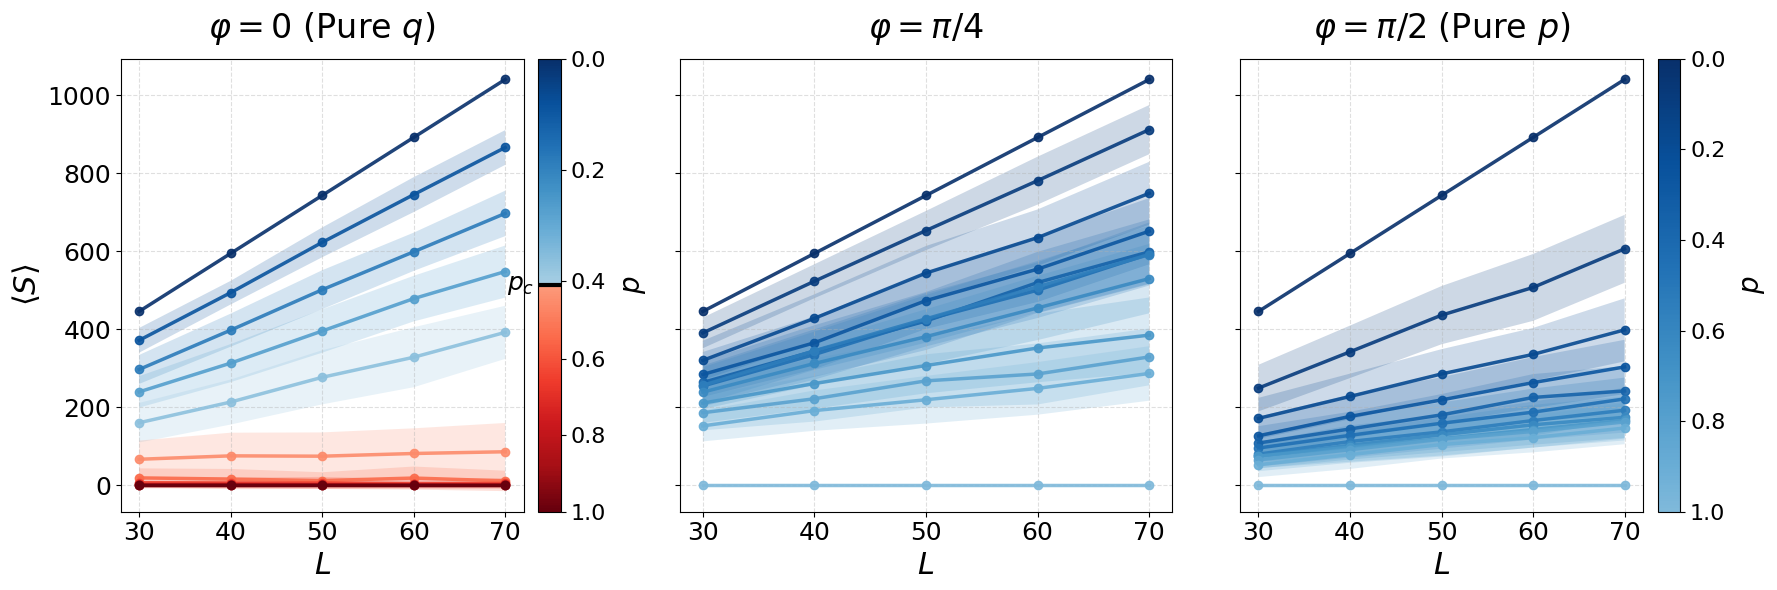

In [37]:
# ==========================================
# 3. SCRIPT EXECUTION
# ==========================================
if __name__ == "__main__":
    # Your file paths
    file_name = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_5.0_phi_0.0000.pkl"
    file_name_2 = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_5.0_phi_0.7854.pkl"
    file_name_3 = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_5.0_phi_1.5708.pkl"

    # Parameters
    p_c = 0.4078
    
    # --- FIXED: Load the standard deviations (S1_std, S2_std, S3_std) ---
    p1, dim1, _, _, S1, S1_std = initialize_data(file_name, meas='general')
    p2, dim2, _, _, S2, S2_std = initialize_data(file_name_2, meas='general')
    p3, dim3, _, _, S3, S3_std = initialize_data(file_name_3, meas='general')

    # --- FIXED: Pack the standard deviations into the datasets ---
    data_list = [
        (p1, dim1, S1, S1_std),
        (p2, dim2, S2, S2_std),
        (p3, dim3, S3, S3_std)
    ]
    
    # Custom titles for the top of each subplot
    titles = [r'$\varphi = 0$ (Pure $q$)', r'$\varphi = \pi/4$', r'$\varphi = \pi/2$ (Pure $p$)']
    
    # Plot it!
    plot_entropy_subplots(data_list, p_c, titles, vmin=0.0, vmax=1.0)

In [40]:
# plot S vs p for a fixed L
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. FIXED L PLOTTING FUNCTION
# ==========================================
def plot_entropy_vs_p_fixed_L(datasets, target_L, phi_labels):
    """
    Plots <S>/L vs p for a specific L across multiple measurement angles.
    datasets: List of tuples (p_values, dimensions, S_matrix, S_matrix_std)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Distinct colors and markers for the different angles
    colors = ['#08519c', '#cb181d', '#238b45']  # Deep Blue, Crimson Red, Forest Green
    markers = ['o', 's', '^']                   # Circle, Square, Triangle

    for i, data in enumerate(datasets):
        p_values, dimensions, S_matrix, S_matrix_std = data
        
        # Safely find the index of the requested L
        if target_L not in dimensions:
            raise ValueError(f"Target L={target_L} not found in dimensions array {dimensions}")
        
        l_idx = np.where(dimensions == target_L)[0][0]
        
        # Extract the specific row for our target L
        means = S_matrix[l_idx, :]
        stds = S_matrix_std[l_idx, :]
        
        # Plot the main line
        # markevery=5 prevents the 150 data points from overlapping into a solid blob
        ax.plot(p_values, means, marker=markers[i], color=colors[i], 
                linewidth=2.5, markersize=7, label=phi_labels[i], 
                alpha=0.9, markevery=5)
        
        # Add the shaded standard deviation region
        ax.fill_between(p_values, means - stds, means + stds, 
                        color=colors[i], alpha=0.15, edgecolor='none')

    # ==========================================
    # 2. PLOT FORMATTING
    # ==========================================
    ax.set_xlabel(r"$p$", fontsize=22)
    ax.set_ylabel(r"$\langle S \rangle / L$", fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # Scientific notation on Y axis
    #ax.ticklabel_format(style='sci', axis='y', scilimits=(3, 3), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(16)
    
    # Bound the X-axis strictly to the p domain
    ax.set_xlim(p_values[0], p_values[-1])
    
    # Create a nice legend
    ax.legend(fontsize=18, loc='best', frameon=True, edgecolor='black', shadow=True)
    
    ax.grid(alpha=0.4, linestyle='--')

    plt.tight_layout()
    plt.show()



[INFO] Successfully loaded 150 / 150 completed p-values.
[INFO] Successfully loaded 150 / 150 completed p-values.
[INFO] Successfully loaded 150 / 150 completed p-values.


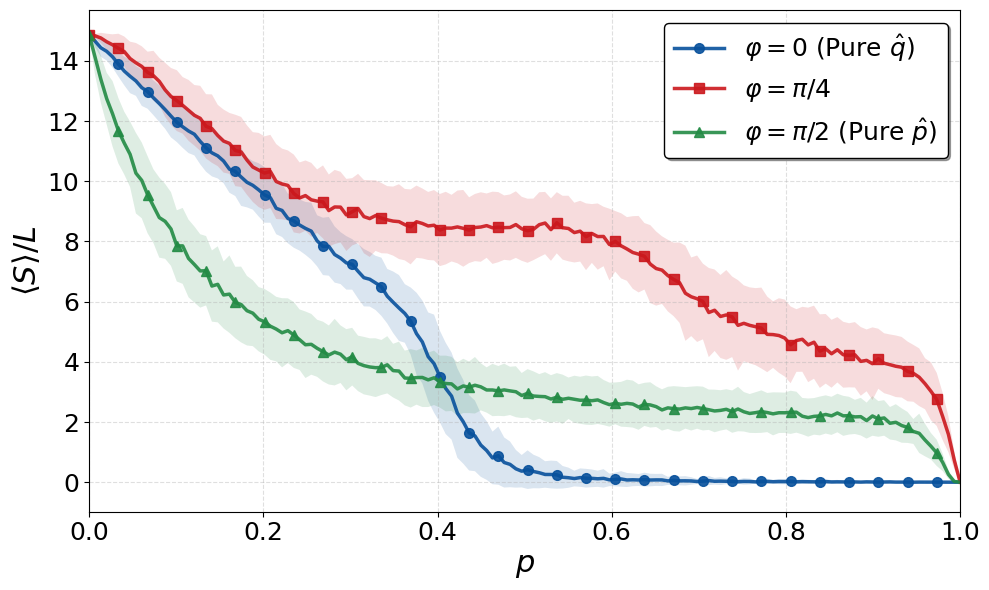

In [41]:
# ==========================================
# 3. SCRIPT EXECUTION
# ==========================================
if __name__ == "__main__":
    # Your file paths
    file_name = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_5.0_phi_0.0000.pkl"
    file_name_2 = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_5.0_phi_0.7854.pkl"
    file_name_3 = r"C:\Users\megido\Downloads\thesis\QUANTUM NETWORKS\data files\data_topology_square_general\Raw_Graph_Data_w_1.0_r_5.0_phi_1.5708.pkl"

    # Load data for all three files
    p1, dim1, _, _, S1, S1_std = initialize_data(file_name, meas='general')
    p2, dim2, _, _, S2, S2_std = initialize_data(file_name_2, meas='general')
    p3, dim3, _, _, S3, S3_std = initialize_data(file_name_3, meas='general')

    # Pack the data to pass into the subplot function
    data_list = [
        (p1, dim1, S1, S1_std),
        (p2, dim2, S2, S2_std),
        (p3, dim3, S3, S3_std)
    ]
    
    # Custom labels for the legend
    labels = [r'$\varphi = 0$ (Pure $\hat{q}$)', r'$\varphi = \pi/4$', r'$\varphi = \pi/2$ (Pure $\hat{p}$)']
    
    # Select which L you want to inspect
    target_L = 70 
    
    # Plot it!
    plot_entropy_vs_p_fixed_L(data_list, target_L, labels)